In [1]:
!pip -q install pyddm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pyddm

color1 = '#01ba38'
color2 = '#f9766e'
color3 = '#619dff'

In [4]:
df = pd.read_csv("dataset-2.tsv", sep="\t")
df["correct"] = (df["S"] == df["R"]).astype(int)
df["compatible"] = ((df["picture"] == "ingroup") & (df["S"] == "positive")) | ((df["picture"] == "outgroup") & (df["S"] == "negative"))
df["condition"] = np.where(df["compatible"], "compatible", "incompatible")
subjects = sorted(df["subjects"].unique())
df.head()

print(f"Number of subjects: {len(subjects)}")
print(f"Number of compatible trials: {df['compatible'].sum()}")
print(f"Number of incompatible trials: {len(df) - df['compatible'].sum()}")

Number of subjects: 12
Number of compatible trials: 2760
Number of incompatible trials: 2760


In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

Subject 1: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.655 s, accuracy = 0.743
Subject 2: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.621 s, accuracy = 0.737
Subject 3: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.459 s, accuracy = 0.761
Subject 4: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.493 s, accuracy = 0.709
Subject 5: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.573 s, accuracy = 0.654
Subject 6: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.465 s, accuracy = 0.752
Subject 7: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.495 s, accuracy = 0.652
Subject 8: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.565 s, accuracy = 0.750
Subject 9: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.594 s, accuracy = 0.654
Subject 10: 460 trials (230 compatible, 230 incompatible),  mean RT = 0.564 s, accuracy = 0.750
Subject 11: 460 trials (230 compatible, 230 incom

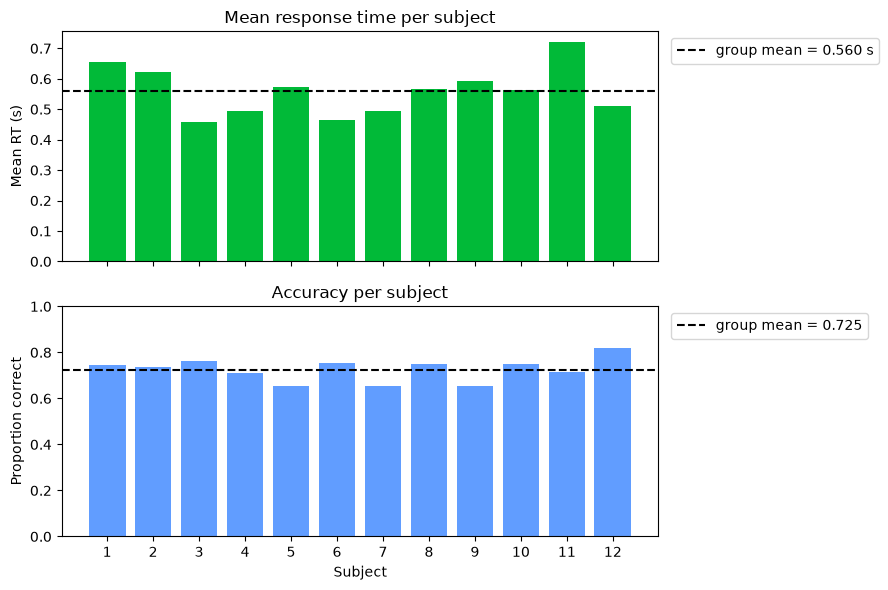

In [7]:
means, accs = [], []
for s in subjects:
    d = df[df["subjects"] == s]
    sample = pyddm.Sample.from_pandas_dataframe(d, rt_column_name="rt", choice_column_name="correct")
    means.append(sample.mean_rt())
    accs.append(sample.prob("correct"))
    print(f"Subject {s}: {len(d)} trials ({d['compatible'].sum()} compatible, {len(d) - d['compatible'].sum()} incompatible),  mean RT = {means[-1]:.3f} s, accuracy = {accs[-1]:.3f}")

labels = [str(s) for s in subjects]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax1.bar(labels, means, color=color1)
ax1.axhline(np.mean(means), color="k", ls="--", label=f"group mean = {np.mean(means):.3f} s")
ax1.set_title("Mean response time per subject")
ax1.set_ylabel("Mean RT (s)")
ax1.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

ax2.bar(labels, accs, color=color3)
ax2.axhline(np.mean(accs), color="k", ls="--", label=f"group mean = {np.mean(accs):.3f}")
ax2.set_ylim(0, 1)
ax2.set_title("Accuracy per subject")
ax2.set_xlabel("Subject")
ax2.set_ylabel("Proportion correct")
ax2.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

plt.tight_layout()

# Are people more accurate on compatible trials?

condition
compatible      0.791667
incompatible    0.657609
dtype: float64
TtestResult(statistic=np.float64(4.574211916959813), pvalue=np.float64(0.0007978596048222558), df=np.int64(11))


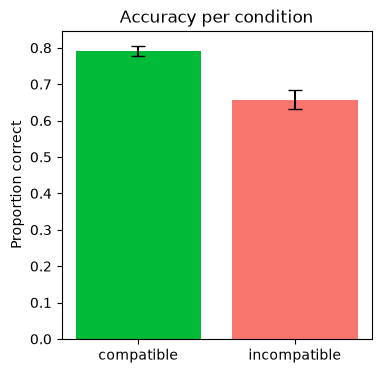

In [9]:
acc = df.groupby(["subjects", "condition"])["correct"].mean().unstack()
print(acc.mean())
print(stats.ttest_rel(acc["compatible"], acc["incompatible"]))

plt.figure(figsize=(4, 4))
plt.bar(["compatible", "incompatible"], acc.mean(), yerr=acc.sem(), capsize=5, color=[color1, color2])
plt.ylabel("Proportion correct")
plt.title("Accuracy per condition")
plt.show()

# Does Mean DT differ on compatible vs incombatible trials?

condition
compatible      0.541525
incompatible    0.590688
dtype: float64
TtestResult(statistic=np.float64(-4.930662717072405), pvalue=np.float64(0.0004491928595400453), df=np.int64(11))


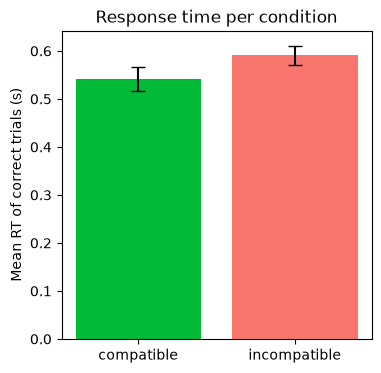

In [10]:
rt = df[df["correct"] == 1].groupby(["subjects", "condition"])["rt"].mean().unstack()
print(rt.mean())
print(stats.ttest_rel(rt["compatible"], rt["incompatible"]))

plt.figure(figsize=(4, 4))
plt.bar(["compatible", "incompatible"], rt.mean(), yerr=rt.sem(), capsize=5, color=[color1, color2])
plt.ylabel("Mean RT of correct trials (s)")
plt.title("Response time per condition")
plt.show()

# Do the RT distributions differ between conditions?

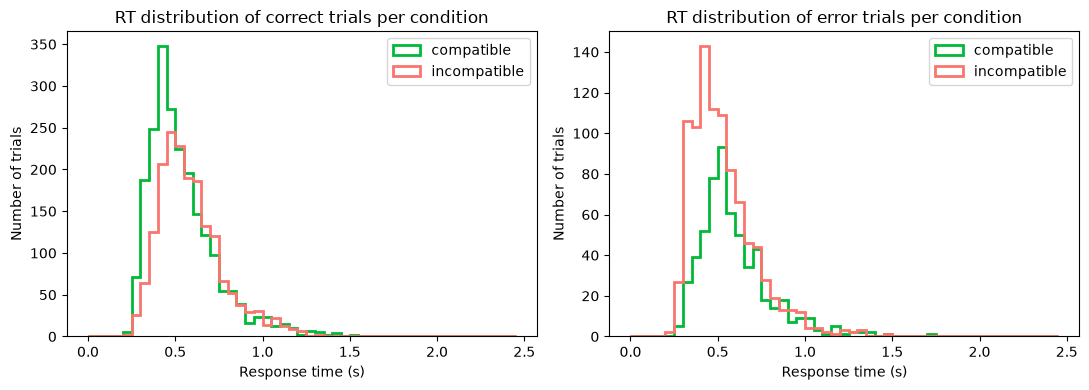

Pooled over all subjects (RT in seconds):
                      n_trials   mean  median     sd
correct condition                                   
error   compatible         575  0.594   0.547  0.200
        incompatible       945  0.529   0.489  0.184
correct compatible        2185  0.539   0.492  0.195
        incompatible      1815  0.589   0.551  0.192

Correct trials, per-subject means (12 subjects):
  compatible = 0.542 s, incompatible = 0.591 s, difference = -49 ms
  paired t-test: t(11) = -4.93, p = 0.0004

Error trials, per-subject means (12 subjects):
  compatible = 0.585 s, incompatible = 0.532 s, difference = 53 ms
  paired t-test: t(11) = 4.29, p = 0.0013

Error RT minus correct RT (negative = errors are faster):
  compatible: 44 ms, t(11) = 4.14, p = 0.0016
  incompatible: -59 ms, t(11) = -5.51, p = 0.0002


In [11]:
bins = np.arange(0, 2.5, 0.05)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, outcome, name in [(axes[0], 1, "correct"), (axes[1], 0, "error")]:
    for cond, col in [("compatible", color1), ("incompatible", color2)]:
        rts = df[(df["condition"] == cond) & (df["correct"] == outcome)]["rt"]
        ax.hist(rts, bins=bins, histtype="step", lw=2, color=col, label=cond)
    ax.set_xlabel("Response time (s)")
    ax.set_ylabel("Number of trials")
    ax.set_title(f"RT distribution of {name} trials per condition")
    ax.legend()
plt.tight_layout()
plt.show()

# 1. Descriptive statistics, pooled over all subjects
summary = df.groupby(["correct", "condition"])["rt"].agg(n_trials="count", mean="mean", median="median", sd="std")
summary.index = summary.index.set_levels(["error", "correct"], level=0)
print("Pooled over all subjects (RT in seconds):")
print(summary.round(3))

# 2. Compatible vs incompatible, separately for correct and error trials (per-subject means)
for outcome, name in [(1, "correct"), (0, "error")]:
    per_sub = df[df["correct"] == outcome].groupby(["subjects", "condition"])["rt"].mean().unstack().dropna()
    t = stats.ttest_rel(per_sub["compatible"], per_sub["incompatible"])
    diff = per_sub["compatible"] - per_sub["incompatible"]
    print(f"\n{name.capitalize()} trials, per-subject means ({len(per_sub)} subjects):")
    print(f"  compatible = {per_sub['compatible'].mean():.3f} s, incompatible = {per_sub['incompatible'].mean():.3f} s, "
          f"difference = {diff.mean()*1000:.0f} ms")
    print(f"  paired t-test: t({len(per_sub)-1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

# 3. Are errors faster or slower than correct responses?
err = df[df["correct"] == 0].groupby(["subjects", "condition"])["rt"].mean().unstack()
cor = df[df["correct"] == 1].groupby(["subjects", "condition"])["rt"].mean().unstack()
d = (err - cor).dropna()
print("\nError RT minus correct RT (negative = errors are faster):")
for cond in ["compatible", "incompatible"]:
    t = stats.ttest_1samp(d[cond], 0)
    print(f"  {cond}: {d[cond].mean()*1000:.0f} ms, t({len(d)-1}) = {t.statistic:.2f}, p = {t.pvalue:.4f}")

 there are significantly more errors in the incompatible trials of our dataset.
Also that correct responses are faster on compatible trials, and errors are faster on incompatible trials.